<a href="https://colab.research.google.com/github/SadatSKD/CSE425-Project/blob/main/GNN_BERT_Music_Context_Colab_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GNN–BERT for Understanding Context from Music (CSE425 / EEE474 / CSE715)

**All four tasks · MusicCaps + GTZAN · tuned for free Colab (T4).**

Run cells top-to-bottom. Everything (audio, features, graphs, checkpoints) is saved to
Google Drive so a session timeout never costs you work — re-running skips finished steps.

**Task map**
1. **BERT** multi-label tag classifier (caption → tags)
2. **GNN** (GraphSAGE) on audio segment-graphs (GTZAN genre) + CNN baseline
3. **GNN–BERT fusion** (cross-attention) + ablations + t-SNE
4. **Contrastive** dual-encoder (InfoNCE) + retrieval R@K

> Before running: **Runtime → Change runtime type → T4 GPU**.


## Fixes applied in this revision

A first pass through this notebook produced several results that were worse than the
random baseline (Task 1 macro-F1 below random; Task 3 concat/xattn macro/micro-F1 exactly
0.000; Task 4 retrieval at chance level) plus a couple of missing deliverables. This
revision addresses the code-level causes:

1. **Class-imbalance collapse (Tasks 1 & 3).** A fixed 0.5 decision threshold on 50 sparse
   tags made models predict "no tag" for most classes, which can score *below* random on
   macro-F1 even when AUC-PR shows real signal. Fixed with a class-weighted
   `BCEWithLogitsLoss` (`pos_weight_from_labels`) and per-tag thresholds tuned on the
   validation split (`tune_thresholds`), applied once to test.
2. **Fusion under-training (Task 3).** The randomly-initialised GNN branch and fusion
   head were sharing BERT's 2e-5 fine-tuning learning rate for only 8 epochs, too slow to
   learn from scratch. Fixed with two parameter groups (BERT stays at 2e-5, GNN/head get
   1e-3), a longer budget, and early stopping on validation AUC-PR.
3. **Unfair Task 2 comparison.** The GNN was model-selected on validation accuracy but the
   CNN baseline trained blind for a fixed 15 epochs with no validation check. The CNN now
   uses the identical selection procedure.
4. **Task 4 overfitting.** Training ran a fixed 10 epochs with the validation split unused;
   train loss kept dropping while test retrieval sat at chance level. Fixed with weight
   decay, dropout in the projection heads, and early stopping / checkpoint selection on
   validation R@5.
5. **Missing deliverables added**: train/val/test splits are now persisted to
   `data/splits/splits.json`; the Task 3 t-SNE is now coloured by both a genre-keyword and
   a mood-keyword proxy (MusicCaps has neither as a ground-truth field, so both are
   keyword-derived — say so in the report); a new cell renders the 3 required case studies
   showing each clip's segment graph next to its caption and predicted/true tags.
6. `musiccaps_n` raised from 1200 → 2500 attempted downloads to offset the ~50% YouTube
   download failure rate seen in the first run, aiming for roughly double the usable clips.

**You still need to re-run this notebook end-to-end in Colab** to get fresh numbers — none
of this could be executed in this review environment (no GPU, and YouTube/HuggingFace/
Kaggle are not reachable from here). Every code cell in this revision was syntax-checked,
not executed against real data.

## 0 · Environment setup

Installs PyTorch Geometric, HuggingFace Transformers, librosa, yt-dlp. Torch/CUDA already ship with Colab.

In [2]:
# --- Installs (a few minutes on first run) ---
import torch
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
!pip -q install torch_geometric
!pip -q install "transformers>=4.40" librosa yt-dlp scikit-learn matplotlib seaborn tqdm
print("Installs done.")

torch: 2.11.0+cu128 | CUDA: True
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 28.9 MB/s eta 0:00:00
Installs done.


In [3]:
# --- Mount Google Drive (persistent storage) ---
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# --- Config: every knob lives here ---
import os, random, numpy as np, torch

CONFIG = {
    "project_dir":   "/content/drive/MyDrive/gnn_bert_music",
    "sample_rate":   22050,
    "n_mels":        128,
    "n_mfcc":        13,
    "n_chroma":      12,
    "segment_sec":   2.0,     # non-overlapping window -> nodes per track
    "sim_threshold": 0.80,    # cosine-sim edge threshold in segment graph
    "max_text_len":  128,
    "musiccaps_n":   2500,    # raised from 1200: ~50% of clips fail to download from YouTube,
                              # so this targets ~1200-1300 usable clips instead of ~600
    "top_k_tags":    50,      # multi-label target vocabulary size
    "bert_model":    "distilbert-base-uncased",
    "batch_size":    16,
    "seed":          42,
    "epochs_bert":   10,      # was 4  -> 4 epochs under-trains a 50-tag head
    "epochs_gnn":    80,      # was 30 -> safe with best-val checkpointing + early stopping below
    "epochs_fusion": 30,      # was 8  -> the randomly-initialised GNN/head need more steps than pretrained BERT
    "epochs_clip":   30,      # was 10 -> paired with early stopping on val retrieval
    "patience":      8,       # early-stopping patience (epochs) for GNN / CNN / fusion / contrastive
    "lr_bert":       2e-5,
    "lr_head":       1e-3,    # for randomly-initialised GNN / fusion-head / projection params
    "weight_decay":  1e-4,
}
NODE_DIM = CONFIG["n_chroma"] + CONFIG["n_mfcc"]   # per-segment feature size = 25

def seed_everything(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_everything(CONFIG["seed"])

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
P = CONFIG["project_dir"]
DIRS = {k: os.path.join(P, k) for k in
        ["raw","processed","splits","graphs","checkpoints","results","plots","retrieval_examples"]}
for d in [P, *DIRS.values()]:
    os.makedirs(d, exist_ok=True)
print("Device:", DEVICE)
print("Project root:", P)

Device: cuda
Project root: /content/drive/MyDrive/gnn_bert_music


## 1 · Data acquisition

**GTZAN** (Task 2 genre benchmark) comes from Kaggle — upload your `kaggle.json`
(Kaggle → Account → Create New API Token) when prompted.

**MusicCaps** metadata is a tiny CSV from HuggingFace; the audio is fetched clip-by-clip
from YouTube with `yt-dlp`. Expect to lose some clips (YouTube blocks Colab IPs) — that's
normal. Downloading resumes automatically on re-run.

In [5]:
# --- 1a. GTZAN via Kaggle (new KGAT_ token format) ---
import os, glob
from getpass import getpass

GTZAN_DIR = os.path.join(DIRS["raw"], "gtzan")
gtzan_audio_root = os.path.join(GTZAN_DIR, "Data", "genres_original")

if not os.path.isdir(gtzan_audio_root):
    # paste the KGAT_... token when prompted (input stays hidden)
    token = getpass("Paste your Kaggle API token (starts with KGAT_): ").strip()
    os.environ["KAGGLE_API_TOKEN"] = token
    kdir = os.path.expanduser("~/.kaggle")
    os.makedirs(kdir, exist_ok=True)
    with open(os.path.join(kdir, "access_token"), "w") as f:
        f.write(token)
    os.chmod(os.path.join(kdir, "access_token"), 0o600)

    !pip -q install --upgrade kaggle
    os.makedirs(GTZAN_DIR, exist_ok=True)
    !kaggle datasets download -d andradaolteanu/gtzan-dataset-music-genre-classification -p "$GTZAN_DIR" --unzip

    hits = glob.glob(os.path.join(GTZAN_DIR, "**", "genres_original"), recursive=True)
    if hits:
        gtzan_audio_root = hits[0]

print("GTZAN audio root:", gtzan_audio_root, "| exists:", os.path.isdir(gtzan_audio_root))
if os.path.isdir(gtzan_audio_root):
    print("genres:", sorted(os.listdir(gtzan_audio_root))[:12])

GTZAN audio root: /content/drive/MyDrive/gnn_bert_music/raw/gtzan/Data/genres_original | exists: True
genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [6]:
# --- 1b. MusicCaps metadata (captions + aspect tags) ---
import pandas as pd
mc_csv = os.path.join(DIRS["raw"], "musiccaps-public.csv")
if not os.path.exists(mc_csv):
    !wget -q -O "$mc_csv" https://huggingface.co/datasets/google/MusicCaps/resolve/main/musiccaps-public.csv
mc = pd.read_csv(mc_csv)
print("MusicCaps rows:", len(mc))
print("columns:", list(mc.columns))
mc.head(2)

MusicCaps rows: 5521
columns: ['ytid', 'start_s', 'end_s', 'audioset_positive_labels', 'aspect_list', 'caption', 'author_id', 'is_balanced_subset', 'is_audioset_eval']


,ytid,start_s,end_s,audioset_positive_labels,aspect_list,caption,author_id,is_balanced_subset,is_audioset_eval
0,-0Gj8-vB1q4,30,40,"/m/0140xf,/m/02cjck,/m/04rlf","['low quality', 'sustained strings melody', 's...",The low quality recording features a ballad so...,4,False,True
1,-0SdAVK79lg,30,40,"/m/0155w,/m/01lyv,/m/0342h,/m/042v_gx,/m/04rlf...","['guitar song', 'piano backing', 'simple percu...",This song features an electric guitar as the m...,0,False,False


In [7]:
# --- 1c. Download a MusicCaps audio subset (resumable) ---
# Each row -> 10s clip [start_s, end_s] from a YouTube id, saved as 22.05k mono wav.
import subprocess, os
from tqdm.auto import tqdm

MC_AUDIO = os.path.join(DIRS["raw"], "musiccaps_wav")
os.makedirs(MC_AUDIO, exist_ok=True)
sr = CONFIG["sample_rate"]

subset = mc.sample(n=min(CONFIG["musiccaps_n"], len(mc)), random_state=CONFIG["seed"]).reset_index(drop=True)

def fetch_clip(ytid, start, end, out_wav):
    if os.path.exists(out_wav):
        return True
    url = f"https://www.youtube.com/watch?v={ytid}"
    tmp = out_wav + ".full.m4a"
    try:
        subprocess.run(["yt-dlp","-q","--no-warnings","-f","bestaudio","-x",
                        "--audio-format","m4a","-o",tmp,url],
                       check=True, timeout=90,
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        real = tmp if os.path.exists(tmp) else tmp.replace(".m4a","")  # yt-dlp may rename
        if not os.path.exists(real):
            cand = [f for f in os.listdir(MC_AUDIO) if f.startswith(os.path.basename(tmp))]
            real = os.path.join(MC_AUDIO, cand[0]) if cand else tmp
        subprocess.run(["ffmpeg","-y","-loglevel","error","-i",real,
                        "-ss",str(start),"-to",str(end),
                        "-ac","1","-ar",str(sr),out_wav],
                       check=True, timeout=60)
        return os.path.exists(out_wav)
    except Exception:
        return False
    finally:
        for f in [tmp]:
            if os.path.exists(f):
                try: os.remove(f)
                except: pass

ok = 0
rows = []
for _, r in tqdm(subset.iterrows(), total=len(subset), desc="MusicCaps dl"):
    out = os.path.join(MC_AUDIO, f"{r['ytid']}.wav")
    got = fetch_clip(r["ytid"], float(r["start_s"]), float(r["end_s"]), out)
    if got:
        ok += 1
        rows.append({"ytid": r["ytid"], "wav": out,
                     "caption": r["caption"], "aspect_list": r["aspect_list"]})
mc_manifest = pd.DataFrame(rows)
mc_manifest.to_csv(os.path.join(DIRS["processed"], "musiccaps_manifest.csv"), index=False)
print(f"Downloaded {ok}/{len(subset)} clips. Manifest rows: {len(mc_manifest)}")
print("If this number is very low, re-run this cell (resumes) or reduce musiccaps_n.")

MusicCaps dl:   0%|          | 0/2500 [00:00<?, ?it/s]

Downloaded 805/2500 clips. Manifest rows: 805
If this number is very low, re-run this cell (resumes) or reduce musiccaps_n.


## 2 · Audio feature extraction

For every clip we compute per-segment features that become **GNN node vectors**, plus a
full **log-mel** (for the CNN baseline). Audio is resampled to 22,050 Hz and split into
non-overlapping `segment_sec` windows. Cached to Drive as `.npz`.

In [8]:
import librosa, numpy as np, os
from tqdm.auto import tqdm

def segment_node_features(y, sr):
    """Return [n_segments, NODE_DIM] = per-window mean(chroma-12 + mfcc-13)."""
    seg = int(CONFIG["segment_sec"] * sr)
    if len(y) < seg:
        y = np.pad(y, (0, seg - len(y)))
    n = len(y) // seg
    feats = []
    for i in range(n):
        w = y[i*seg:(i+1)*seg]
        chroma = librosa.feature.chroma_stft(y=w, sr=sr, n_chroma=CONFIG["n_chroma"]).mean(axis=1)
        mfcc   = librosa.feature.mfcc(y=w, sr=sr, n_mfcc=CONFIG["n_mfcc"]).mean(axis=1)
        feats.append(np.concatenate([chroma, mfcc]))
    F = np.stack(feats).astype(np.float32)              # [n, 25]
    F = (F - F.mean(0, keepdims=True)) / (F.std(0, keepdims=True) + 1e-6)
    return F

def log_mel(y, sr, fixed_frames=None):
    m = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=CONFIG["n_mels"])
    m = librosa.power_to_db(m, ref=np.max)
    m = (m - m.mean()) / (m.std() + 1e-6)
    if fixed_frames:                                    # pad/crop for the CNN baseline
        if m.shape[1] < fixed_frames:
            m = np.pad(m, ((0,0),(0, fixed_frames - m.shape[1])))
        else:
            m = m[:, :fixed_frames]
    return m.astype(np.float32)

def extract_and_cache(wav_path, cache_path, fixed_frames=None):
    if os.path.exists(cache_path):
        return True
    try:
        y, sr = librosa.load(wav_path, sr=CONFIG["sample_rate"], mono=True)
        if len(y) < CONFIG["sample_rate"]:              # <1s -> skip
            return False
        nodes = segment_node_features(y, sr)
        mel   = log_mel(y, sr, fixed_frames=fixed_frames)
        np.savez_compressed(cache_path, nodes=nodes, mel=mel)
        return True
    except Exception:
        return False
print("Feature functions ready. NODE_DIM =", NODE_DIM)

Feature functions ready. NODE_DIM = 25


In [9]:
# --- 2a. GTZAN features (30s clips -> fix CNN mel to 1024 frames) ---
import glob
FEAT_GTZAN = os.path.join(DIRS["processed"], "gtzan"); os.makedirs(FEAT_GTZAN, exist_ok=True)
GTZAN_FIXED_FRAMES = 1024
gtzan_wavs = sorted(glob.glob(os.path.join(gtzan_audio_root, "*", "*.wav")))
print("GTZAN wavs found:", len(gtzan_wavs))
gz_ok = 0
for w in tqdm(gtzan_wavs, desc="GTZAN feats"):
    genre = os.path.basename(os.path.dirname(w))
    cid = f"{genre}__{os.path.splitext(os.path.basename(w))[0]}"
    if extract_and_cache(w, os.path.join(FEAT_GTZAN, cid + ".npz"), fixed_frames=GTZAN_FIXED_FRAMES):
        gz_ok += 1
print("GTZAN cached:", gz_ok)

GTZAN wavs found: 1000


GTZAN feats:   0%|          | 0/1000 [00:00<?, ?it/s]

/tmp/ipykernel_1404/3211890122.py:35: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(wav_path, sr=CONFIG["sample_rate"], mono=True)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


GTZAN cached: 999


In [10]:
# --- 2b. MusicCaps features (10s clips -> fix CNN mel to 448 frames) ---
import pandas as pd
FEAT_MC = os.path.join(DIRS["processed"], "musiccaps"); os.makedirs(FEAT_MC, exist_ok=True)
MC_FIXED_FRAMES = 448
mc_manifest = pd.read_csv(os.path.join(DIRS["processed"], "musiccaps_manifest.csv"))
mc_ok = []
for _, r in tqdm(mc_manifest.iterrows(), total=len(mc_manifest), desc="MusicCaps feats"):
    cid = r["ytid"]
    if extract_and_cache(r["wav"], os.path.join(FEAT_MC, cid + ".npz"), fixed_frames=MC_FIXED_FRAMES):
        mc_ok.append(cid)
print("MusicCaps cached:", len(mc_ok))

MusicCaps feats:   0%|          | 0/805 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


MusicCaps cached: 804


## 3 · Segment-similarity graph construction

One PyG graph per track. **Nodes** = segments (features from §2). **Edges** = temporal
adjacency (`i↔i+1`) plus recurrence links (`cos(i,j) > sim_threshold`, capturing repeated
choruses). We attach labels and — for MusicCaps — the tokenized caption so the DataLoader
batches text alongside the graph.

In [11]:
from torch_geometric.data import Data
import numpy as np, torch, os

def build_graph(nodes, tau=None):
    tau = CONFIG["sim_threshold"] if tau is None else tau
    N = nodes.shape[0]
    x = torch.tensor(nodes, dtype=torch.float)
    src, dst = [], []
    for i in range(N-1):                       # temporal adjacency (both directions)
        src += [i, i+1]; dst += [i+1, i]
    if N > 1:                                   # cosine-similarity recurrence edges
        Xn = x / (x.norm(dim=1, keepdim=True) + 1e-8)
        S = (Xn @ Xn.t()).numpy()
        for i in range(N):
            for j in range(i+2, N):
                if S[i, j] > tau:
                    src += [i, j]; dst += [j, i]
    if not src:                                 # fallback self-loop for 1-node graphs
        src, dst = [0], [0]
    edge_index = torch.tensor([src, dst], dtype=torch.long)
    return Data(x=x, edge_index=edge_index)
print("Graph builder ready.")

Graph builder ready.


## 4 · Labels, tokenization & splits

- **GTZAN** → single genre class (Task 2).
- **MusicCaps** → multi-hot over the **top-K aspect tags** (Tasks 1/3/4) + tokenized caption.

Splits are stratified/random with fixed seed; graphs are exported to Drive (≥20 example
`.pt` files, a required deliverable).

In [12]:
# --- 4a. GTZAN graph dataset (genre classification) ---
import glob, torch, os
gtzan_files = sorted(glob.glob(os.path.join(FEAT_GTZAN, "*.npz")))
GENRES = sorted({os.path.basename(f).split("__")[0] for f in gtzan_files})
G2I = {g:i for i,g in enumerate(GENRES)}
print("GTZAN genres:", GENRES)

gtzan_graphs = []
for f in gtzan_files:
    d = np.load(f)
    g = build_graph(d["nodes"])
    g.y = torch.tensor([G2I[os.path.basename(f).split("__")[0]]], dtype=torch.long)
    g.mel = torch.tensor(d["mel"]).unsqueeze(0)         # [1,128,1024] for CNN baseline
    gtzan_graphs.append(g)
print("GTZAN graphs:", len(gtzan_graphs))

GTZAN genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
GTZAN graphs: 999


In [13]:
# --- 4b. MusicCaps: build top-K tag vocab, multi-hot labels, tokenize captions ---
from collections import Counter
from transformers import AutoTokenizer
import ast, torch

TOK = AutoTokenizer.from_pretrained(CONFIG["bert_model"])

def parse_aspects(a):
    try:
        v = ast.literal_eval(a) if isinstance(a, str) and a.strip().startswith("[") else str(a).split(",")
    except Exception:
        v = str(a).split(",")
    return [t.strip().lower() for t in v if t and t.strip()]

mc_manifest = pd.read_csv(os.path.join(DIRS["processed"], "musiccaps_manifest.csv"))
mc_manifest = mc_manifest[mc_manifest["ytid"].isin(
    [os.path.splitext(os.path.basename(f))[0] for f in glob.glob(os.path.join(FEAT_MC,"*.npz"))])].reset_index(drop=True)

cnt = Counter()
for a in mc_manifest["aspect_list"]:
    cnt.update(parse_aspects(a))
TAGS = [t for t,_ in cnt.most_common(CONFIG["top_k_tags"])]
T2I = {t:i for i,t in enumerate(TAGS)}
K = len(TAGS)
print(f"Tag vocabulary K={K}. Sample:", TAGS[:12])

def multi_hot(aspects):
    v = torch.zeros(K)
    for a in aspects:
        if a in T2I: v[T2I[a]] = 1.0
    return v

mc_graphs = []
for _, r in mc_manifest.iterrows():
    d = np.load(os.path.join(FEAT_MC, r["ytid"] + ".npz"))
    g = build_graph(d["nodes"])
    g.y = multi_hot(parse_aspects(r["aspect_list"])).unsqueeze(0)      # [1,K]
    enc = TOK(str(r["caption"]), truncation=True, padding="max_length",
              max_length=CONFIG["max_text_len"], return_tensors="pt")
    g.input_ids = enc["input_ids"]                                     # [1,L]
    g.attention_mask = enc["attention_mask"]                          # [1,L]
    g.mel = torch.tensor(d["mel"]).unsqueeze(0)
    g.caption = r["caption"]
    mc_graphs.append(g)
print("MusicCaps graphs:", len(mc_graphs))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tag vocabulary K=50. Sample: ['low quality', 'instrumental', 'amateur recording', 'energetic', 'emotional', 'passionate', 'medium tempo', 'noisy', 'slow tempo', 'live performance', 'fast tempo', 'groovy']
MusicCaps graphs: 804


In [14]:
# --- 4c. Splits + export >=20 example graphs (required deliverable) ---
import random, torch, os, json
random.seed(CONFIG["seed"])

def split_idx(n, tr=0.7, va=0.15):
    idx = list(range(n)); random.shuffle(idx)
    a, b = int(tr*n), int((tr+va)*n)
    return idx[:a], idx[a:b], idx[b:]

gz_tr, gz_va, gz_te = split_idx(len(gtzan_graphs))
mc_tr, mc_va, mc_te = split_idx(len(mc_graphs))
print(f"GTZAN split  {len(gz_tr)}/{len(gz_va)}/{len(gz_te)}")
print(f"MusicCaps    {len(mc_tr)}/{len(mc_va)}/{len(mc_te)}")

# Persist splits to data/splits/*.json (required by the repo structure in the spec).
# Note on artist leakage: GTZAN filenames and MusicCaps ytids carry no reliable artist
# field, so a per-artist leakage check isn't possible with the metadata these datasets
# expose -- splits are random-seeded only. State this limitation explicitly in the report.
splits_payload = {
    "gtzan":     {"train": gz_tr, "val": gz_va, "test": gz_te},
    "musiccaps": {"train": mc_tr, "val": mc_va, "test": mc_te},
    "seed": CONFIG["seed"],
}
with open(os.path.join(DIRS["splits"], "splits.json"), "w") as f:
    json.dump(splits_payload, f, indent=2)
print("Splits saved ->", os.path.join(DIRS["splits"], "splits.json"))

for i, g in enumerate(mc_graphs[:20]):
    torch.save(g, os.path.join(DIRS["graphs"], f"musiccaps_example_{i:02d}.pt"))
print("Exported 20 example graphs ->", DIRS["graphs"])

GTZAN split  699/150/150
MusicCaps    562/121/121
Splits saved -> /content/drive/MyDrive/gnn_bert_music/splits/splits.json
Exported 20 example graphs -> /content/drive/MyDrive/gnn_bert_music/graphs


## 5 · Shared metrics & helpers

Macro/Micro-F1 and mean AUC-PR for multi-label; accuracy for GTZAN. Used by every task.

In [15]:
import numpy as np, torch
from sklearn.metrics import f1_score, average_precision_score, accuracy_score
from torch_geometric.loader import DataLoader

def multilabel_metrics(y_true, y_prob, thr=0.5):
    """thr: float (applied to every tag) OR a per-tag array of length K."""
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    thr_arr = np.asarray(thr) if np.ndim(thr) > 0 else thr
    y_pred = (y_prob >= thr_arr).astype(int)
    keep = y_true.sum(0) > 0                      # AUC-PR needs a positive
    try:    aucpr = average_precision_score(y_true[:,keep], y_prob[:,keep], average="macro")
    except Exception: aucpr = float("nan")
    return {"macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
            "auc_pr":   float(aucpr)}

def tune_thresholds(y_val, p_val, grid=None):
    """Per-tag threshold that maximises that tag's F1 on the validation set.
    Fixes the multi-label pitfall where a blanket 0.5 threshold makes a model
    predict 'no tag' everywhere under heavy class imbalance -- which can score
    *below* a random baseline on macro-F1 even when the model has real signal
    (visible in AUC-PR). Falls back to 0.5 for tags with no positive val examples."""
    y_val = np.asarray(y_val); p_val = np.asarray(p_val)
    grid = np.linspace(0.05, 0.95, 19) if grid is None else grid
    K = y_val.shape[1]
    thr = np.full(K, 0.5, dtype=np.float32)
    for k in range(K):
        if y_val[:, k].sum() == 0:
            continue
        best_f1, best_t = -1.0, 0.5
        for t in grid:
            f1 = f1_score(y_val[:, k], (p_val[:, k] >= t).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        thr[k] = best_t
    return thr

def pos_weight_from_labels(y_train, cap=20.0):
    """BCEWithLogitsLoss pos_weight per tag = n_negative / n_positive, capped so a
    handful of ultra-rare tags don't destabilise training."""
    y_train = np.asarray(y_train)
    pos = y_train.sum(0); neg = y_train.shape[0] - pos
    w = np.where(pos > 0, neg / np.maximum(pos, 1), 1.0)
    w = np.clip(w, 1.0, cap)
    return torch.tensor(w, dtype=torch.float32)

def loaders(graphs, tr, va, te, bs=None):
    bs = bs or CONFIG["batch_size"]
    mk = lambda idx, sh: DataLoader([graphs[i] for i in idx], batch_size=bs, shuffle=sh)
    return mk(tr, True), mk(va, False), mk(te, False)
print("Metrics ready (with pos_weight + per-tag threshold tuning).")

Metrics ready (with pos_weight + per-tag threshold tuning).


## 6 · Task 1 (Easy) — DistilBERT multi-label tag classifier

`t = BERT_CLS(caption)`, `ŷ = σ(W t)`, trained with per-tag BCE. Text-only baseline;
Tasks 2–3 must reach the *same* tags from audio structure.

In [16]:
import torch, torch.nn as nn, os
from transformers import AutoModel

class BertTagger(nn.Module):
    def __init__(self, K, name=CONFIG["bert_model"]):
        super().__init__()
        self.bert = AutoModel.from_pretrained(name)
        self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(self.bert.config.hidden_size, K))
    def encode(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0]                    # CLS token
    def forward(self, input_ids, attention_mask):
        return self.head(self.encode(input_ids, attention_mask))

def run_epoch_bert(model, loader, opt=None, crit=None):
    train = opt is not None
    model.train() if train else model.eval()
    crit = crit or nn.BCEWithLogitsLoss()
    tot, ys, ps = 0.0, [], []
    for b in loader:
        ids, am, y = b.input_ids.to(DEVICE), b.attention_mask.to(DEVICE), b.y.to(DEVICE)
        with torch.set_grad_enabled(train):
            logits = model(ids, am); loss = crit(logits, y)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item()*y.size(0)
        ys.append(y.cpu().numpy()); ps.append(torch.sigmoid(logits).detach().cpu().numpy())
    return tot/len(loader.dataset), np.concatenate(ys), np.concatenate(ps)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ep1 loss=1.164 val_macroF1=0.190 microF1=0.198 AUCPR=0.313
ep2 loss=0.985 val_macroF1=0.229 microF1=0.243 AUCPR=0.369
ep3 loss=0.859 val_macroF1=0.259 microF1=0.276 AUCPR=0.422
ep4 loss=0.784 val_macroF1=0.274 microF1=0.291 AUCPR=0.439
ep5 loss=0.731 val_macroF1=0.295 microF1=0.307 AUCPR=0.450
ep6 loss=0.689 val_macroF1=0.312 microF1=0.329 AUCPR=0.468
ep7 loss=0.653 val_macroF1=0.320 microF1=0.339 AUCPR=0.489
ep8 loss=0.613 val_macroF1=0.345 microF1=0.370 AUCPR=0.498
ep9 loss=0.580 val_macroF1=0.345 microF1=0.379 AUCPR=0.498
ep10 loss=0.562 val_macroF1=0.373 microF1=0.410 AUCPR=0.538
TASK 1 test (thr=0.5)      : {'macro_f1': 0.39079051167209683, 'micro_f1': 0.4162203519510329, 'auc_pr': 0.5260374530498977}
TASK 1 test (tuned thresh) : {'macro_f1': 0.41648257186115983, 'micro_f1': 0.4206426484907498, 'auc_pr': 0.5260374530498977}


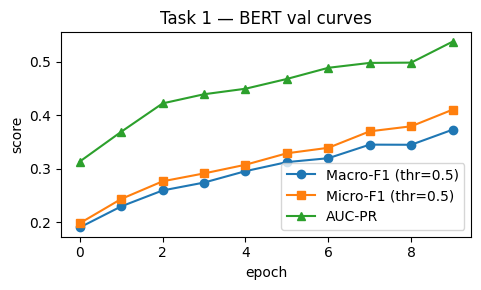

In [17]:
# --- Train Task 1 ---
import matplotlib.pyplot as plt
tr_ld, va_ld, te_ld = loaders(mc_graphs, mc_tr, mc_va, mc_te)
bert = BertTagger(K).to(DEVICE)
opt = torch.optim.AdamW(bert.parameters(), lr=CONFIG["lr_bert"], weight_decay=CONFIG["weight_decay"])

y_train_np = np.stack([mc_graphs[i].y[0].numpy() for i in mc_tr])
pw = pos_weight_from_labels(y_train_np).to(DEVICE)
crit = nn.BCEWithLogitsLoss(pos_weight=pw)   # fixes the "predict nothing" collapse under tag imbalance

hist = {"macro_f1": [], "micro_f1": [], "auc_pr": []}
best_aucpr, best_state, bad_epochs = -1.0, None, 0
for ep in range(CONFIG["epochs_bert"]):
    trl, _, _ = run_epoch_bert(bert, tr_ld, opt, crit)
    _, yv, pv = run_epoch_bert(bert, va_ld, crit=crit)
    m = multilabel_metrics(yv, pv)             # 0.5 threshold, just for the training curve
    hist["macro_f1"].append(m["macro_f1"]); hist["micro_f1"].append(m["micro_f1"]); hist["auc_pr"].append(m["auc_pr"])
    print(f"ep{ep+1} loss={trl:.3f} val_macroF1={m['macro_f1']:.3f} microF1={m['micro_f1']:.3f} AUCPR={m['auc_pr']:.3f}")
    if m["auc_pr"] > best_aucpr:               # AUC-PR is threshold-free -> a fairer stopping signal
        best_aucpr, bad_epochs = m["auc_pr"], 0
        best_state = {k: v.cpu().clone() for k, v in bert.state_dict().items()}
    else:
        bad_epochs += 1
    if bad_epochs >= CONFIG["patience"]:
        print(f"Early stop at ep{ep+1} (no val AUC-PR improvement for {CONFIG['patience']} epochs).")
        break

bert.load_state_dict(best_state)

# Per-tag thresholds tuned on validation, then applied ONCE to the untouched test split.
_, yv, pv = run_epoch_bert(bert, va_ld, crit=crit)
tuned_thr = tune_thresholds(yv, pv)
_, yt, pt = run_epoch_bert(bert, te_ld, crit=crit)
task1_metrics_raw = multilabel_metrics(yt, pt, thr=0.5)
task1_metrics = multilabel_metrics(yt, pt, thr=tuned_thr)      # <- reported metric
print("TASK 1 test (thr=0.5)      :", task1_metrics_raw)
print("TASK 1 test (tuned thresh) :", task1_metrics)
torch.save(bert.state_dict(), os.path.join(DIRS["checkpoints"], "task1_bert.pt"))
np.save(os.path.join(DIRS["checkpoints"], "task1_thresholds.npy"), tuned_thr)

plt.figure(figsize=(5,3))
plt.plot(hist["macro_f1"], marker="o", label="Macro-F1 (thr=0.5)")
plt.plot(hist["micro_f1"], marker="s", label="Micro-F1 (thr=0.5)")
plt.plot(hist["auc_pr"], marker="^", label="AUC-PR")
plt.xlabel("epoch"); plt.ylabel("score"); plt.legend(); plt.title("Task 1 — BERT val curves"); plt.tight_layout()
plt.savefig(os.path.join(DIRS["plots"], "task1_f1.png"), dpi=120); plt.show()

In [18]:
# --- 5 example predictions (deliverable) ---
bert.eval()
for g in mc_graphs[mc_te[0]:mc_te[0]+5] if isinstance(mc_te, list) else []:
    with torch.no_grad():
        p = torch.sigmoid(bert(g.input_ids.to(DEVICE), g.attention_mask.to(DEVICE)))[0].cpu().numpy()
    top = [TAGS[i] for i in p.argsort()[::-1][:5]]
    print("CAPTION:", g.caption[:90])
    print("  pred tags:", top, "\n")

CAPTION: A male vocalist sings this energetic song. The tempo is fast with accordion harmony, funky
  pred tags: ['fast tempo', 'youthful', 'dance music', 'mellow', 'male singer'] 

CAPTION: The low quality recording features a crowd harmonized singing over loud wooden percussion.
  pred tags: ['noisy', 'low quality', 'mono', 'passionate', 'emotional'] 

CAPTION: This music is a Western Classical. The tempo is fast with a lively violin harmony, electri
  pred tags: ['instrumental', 'mellow', 'fast tempo', 'happy', 'upbeat'] 

CAPTION: This song features a didgeridoo being played using the vibration produced by blowing the l
  pred tags: ['no voices', 'no other instruments', 'moderate tempo', 'instrumental', 'bass'] 

CAPTION: This is a movie music piece. Initially, sound effects related to the movie such as explosi
  pred tags: ['male voice', 'percussion', 'no singer', 'piano', 'bass guitar'] 



## 7 · Task 2 (Medium) — GraphSAGE on segment graphs + CNN baseline

GraphSAGE encoder with mean-pool readout for **GTZAN genre**, compared against a 2-D CNN on
the log-mel spectrogram (baseline **B2**).

In [19]:
import torch.nn as nn
from torch_geometric.nn import SAGEConv, global_mean_pool

class GNNEncoder(nn.Module):
    """Shared GraphSAGE encoder -> graph embedding g. Reused in Tasks 3 & 4."""
    def __init__(self, in_dim=NODE_DIM, hid=128, layers=3, out=128, dropout=0.2):
        super().__init__()
        self.convs = nn.ModuleList()
        d = in_dim
        for _ in range(layers-1):
            self.convs.append(SAGEConv(d, hid)); d = hid
        self.convs.append(SAGEConv(d, out))
        self.act = nn.ReLU()
        self.drop = nn.Dropout(dropout)
    def forward(self, x, edge_index, batch):
        for i, c in enumerate(self.convs):
            x = c(x, edge_index)
            if i < len(self.convs)-1:
                x = self.drop(self.act(x))
        return global_mean_pool(x, batch)                     # [B, out]

class GNNClassifier(nn.Module):
    def __init__(self, n_classes, multilabel=False, dropout=0.3):
        super().__init__()
        self.enc = GNNEncoder()
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(128, n_classes))
        self.multilabel = multilabel
    def forward(self, data):
        g = self.enc(data.x, data.edge_index, data.batch)
        return self.head(g)

class MelCNN(nn.Module):
    def __init__(self, n_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1)))
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(64, n_classes))
    def forward(self, mel):                                   # mel [B,1,128,F]
        return self.head(self.net(mel).flatten(1))
print("GNN + CNN defined (with dropout/batchnorm for a fairer, more regularised comparison).")

GNN + CNN defined (with dropout/batchnorm for a fairer, more regularised comparison).


In [20]:
# --- Train GraphSAGE on GTZAN ---
gz_tr_ld, gz_va_ld, gz_te_ld = loaders(gtzan_graphs, gz_tr, gz_va, gz_te)
gnn = GNNClassifier(len(GENRES)).to(DEVICE)
opt = torch.optim.Adam(gnn.parameters(), lr=1e-3, weight_decay=CONFIG["weight_decay"])
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CONFIG["epochs_gnn"])
crit = nn.CrossEntropyLoss()

def eval_gnn(model, loader):
    model.eval(); ys, ps = [], []
    with torch.no_grad():
        for b in loader:
            b = b.to(DEVICE); logits = model(b)
            ys += b.y.cpu().tolist(); ps += logits.argmax(1).cpu().tolist()
    return accuracy_score(ys, ps)

best, bad_epochs = 0, 0
for ep in range(CONFIG["epochs_gnn"]):
    gnn.train()
    for b in gz_tr_ld:
        b = b.to(DEVICE); opt.zero_grad()
        loss = crit(gnn(b), b.y); loss.backward(); opt.step()
    sched.step()
    va = eval_gnn(gnn, gz_va_ld)
    if va > best:
        best, bad_epochs = va, 0
        torch.save(gnn.state_dict(), os.path.join(DIRS["checkpoints"],"task2_gnn.pt"))
    else:
        bad_epochs += 1
    if (ep+1) % 5 == 0: print(f"ep{ep+1} val_acc={va:.3f}")
    if bad_epochs >= CONFIG["patience"]:
        print(f"Early stop at ep{ep+1} (no val-acc improvement for {CONFIG['patience']} epochs)."); break

gnn.load_state_dict(torch.load(os.path.join(DIRS["checkpoints"],"task2_gnn.pt")))
gnn_acc = eval_gnn(gnn, gz_te_ld)
print("TASK 2 GNN test acc:", round(gnn_acc,3))

ep5 val_acc=0.260
ep10 val_acc=0.307
ep15 val_acc=0.300
ep20 val_acc=0.353
ep25 val_acc=0.347
Early stop at ep25 (no val-acc improvement for 8 epochs).
TASK 2 GNN test acc: 0.387


In [21]:
# --- CNN baseline on the same GTZAN split (now with the SAME val-based model
#     selection as the GNN above, for a fair comparison) ---
def gtzan_mel_loader(idx, sh):
    from torch.utils.data import TensorDataset, DataLoader as TDL
    X = torch.stack([gtzan_graphs[i].mel for i in idx])       # [n,1,128,1024]
    Y = torch.tensor([int(gtzan_graphs[i].y) for i in idx])
    return TDL(TensorDataset(X, Y), batch_size=CONFIG["batch_size"], shuffle=sh)

cnn = MelCNN(len(GENRES)).to(DEVICE)
opt = torch.optim.Adam(cnn.parameters(), lr=1e-3, weight_decay=CONFIG["weight_decay"])
tr_m, va_m, te_m = gtzan_mel_loader(gz_tr, True), gtzan_mel_loader(gz_va, False), gtzan_mel_loader(gz_te, False)

def eval_cnn(model, loader):
    model.eval(); ys, ps = [], []
    with torch.no_grad():
        for x, y in loader:
            ps += model(x.to(DEVICE)).argmax(1).cpu().tolist(); ys += y.tolist()
    return accuracy_score(ys, ps)

best, bad_epochs = 0, 0
for ep in range(CONFIG["epochs_gnn"]):          # same epoch budget + patience as the GNN, for fairness
    cnn.train()
    for x, y in tr_m:
        x, y = x.to(DEVICE), y.to(DEVICE); opt.zero_grad()
        loss = crit(cnn(x), y); loss.backward(); opt.step()
    va = eval_cnn(cnn, va_m)
    if va > best:
        best, bad_epochs = va, 0
        torch.save(cnn.state_dict(), os.path.join(DIRS["checkpoints"], "task2_cnn.pt"))
    else:
        bad_epochs += 1
    if bad_epochs >= CONFIG["patience"]:
        print(f"CNN early stop at ep{ep+1}."); break

cnn.load_state_dict(torch.load(os.path.join(DIRS["checkpoints"], "task2_cnn.pt")))
cnn_acc = eval_cnn(cnn, te_m)
print(f"TASK 2 comparison  |  GNN acc={gnn_acc:.3f}   CNN-mel acc={cnn_acc:.3f}")

CNN early stop at ep32.
TASK 2 comparison  |  GNN acc=0.387   CNN-mel acc=0.653


## 8 · Task 3 (Hard) — GNN–BERT fusion (cross-attention) + ablations

Graph embedding `g` (query) attends over BERT token states `H_text`:
`A = softmax(gW_Q · (H W_K)ᵀ / √d)`, `z = concat(g, A·H)`, `ŷ = σ(W z)`.
We run all four ablation arms — **BERT-only, GNN-only, early-concat, cross-attention** — on
the same MusicCaps split and tags.

**Fixes vs. the first pass:** the randomly-initialised GNN branch was barely moving at
BERT's 2e-5 fine-tuning rate in only 8 epochs, so `concat`/`xattn` were collapsing to
"predict no tag" (macro/micro-F1 = 0.000, worse than random). We now use two learning
rates (BERT stays at 2e-5, the GNN + fusion head get 1e-3), a class-weighted loss, a
longer budget with early stopping on validation AUC-PR, and per-tag thresholds tuned on
validation before the single test-set evaluation.

In [22]:
import torch, torch.nn as nn, torch.nn.functional as F

class FusionModel(nn.Module):
    def __init__(self, K, mode="xattn", d=128, dropout=0.3):
        super().__init__()
        self.mode = mode
        self.gnn  = GNNEncoder(out=d)
        self.bert = AutoModel.from_pretrained(CONFIG["bert_model"])
        h = self.bert.config.hidden_size
        self.t_proj = nn.Linear(h, d)
        self.Wq = nn.Linear(d, d); self.Wk = nn.Linear(d, d)
        in_dim = {"bert": d, "gnn": d, "concat": 2*d, "xattn": 2*d}[mode]
        self.head = nn.Sequential(nn.ReLU(), nn.Dropout(dropout), nn.Linear(in_dim, K))
        self.d = d
    def embed(self, data):
        g = self.gnn(data.x, data.edge_index, data.batch)                 # [B,d]
        H = self.t_proj(self.bert(input_ids=data.input_ids,
                                  attention_mask=data.attention_mask).last_hidden_state)  # [B,L,d]
        t = H[:, 0]                                                       # CLS
        if self.mode == "bert":   z = t
        elif self.mode == "gnn":  z = g
        elif self.mode == "concat": z = torch.cat([g, t], -1)
        else:                                                             # cross-attention
            q = self.Wq(g).unsqueeze(1)                                   # [B,1,d]
            k = self.Wk(H)                                                # [B,L,d]
            a = torch.softmax((q @ k.transpose(1,2)) / (self.d**0.5), -1) # [B,1,L]
            ctx = (a @ H).squeeze(1)                                      # [B,d]
            z = torch.cat([g, ctx], -1)
        return z
    def forward(self, data):
        return self.head(self.embed(data))

def train_fusion(mode, pw):
    m = FusionModel(K, mode=mode).to(DEVICE)
    # Two learning rates: BERT is pretrained (small LR); the GNN branch + fusion head
    # are trained from scratch (larger LR). A single shared 2e-5 LR left the randomly
    # initialised GNN/head barely moving in 8 epochs, which is why concat/xattn
    # previously collapsed to predicting "no tag" everywhere.
    bert_params  = list(m.bert.parameters())
    other_params = [p for n, p in m.named_parameters() if not n.startswith("bert.")]
    opt = torch.optim.AdamW([
        {"params": bert_params,  "lr": CONFIG["lr_bert"]},
        {"params": other_params, "lr": CONFIG["lr_head"]},
    ], weight_decay=CONFIG["weight_decay"])
    crit = nn.BCEWithLogitsLoss(pos_weight=pw)
    tr_ld, va_ld, te_ld = loaders(mc_graphs, mc_tr, mc_va, mc_te)

    best_aucpr, best_state, bad_epochs = -1.0, None, 0
    for ep in range(CONFIG["epochs_fusion"]):
        m.train()
        for b in tr_ld:
            b = b.to(DEVICE); opt.zero_grad()
            loss = crit(m(b), b.y); loss.backward(); opt.step()
        m.eval(); yv, pv = [], []
        with torch.no_grad():
            for b in va_ld:
                b = b.to(DEVICE); yv.append(b.y.cpu().numpy()); pv.append(torch.sigmoid(m(b)).cpu().numpy())
        yv, pv = np.concatenate(yv), np.concatenate(pv)
        val_aucpr = multilabel_metrics(yv, pv)["auc_pr"]
        if val_aucpr > best_aucpr:
            best_aucpr, bad_epochs = val_aucpr, 0
            best_state = {k: v.cpu().clone() for k, v in m.state_dict().items()}
        else:
            bad_epochs += 1
        if bad_epochs >= CONFIG["patience"]:
            break
    m.load_state_dict(best_state)

    # Tune per-tag thresholds on val, then evaluate ONCE on the held-out test split.
    m.eval(); yv, pv = [], []
    with torch.no_grad():
        for b in va_ld:
            b = b.to(DEVICE); yv.append(b.y.cpu().numpy()); pv.append(torch.sigmoid(m(b)).cpu().numpy())
    thr = tune_thresholds(np.concatenate(yv), np.concatenate(pv))

    ys, ps = [], []
    with torch.no_grad():
        for b in te_ld:
            b = b.to(DEVICE); ys.append(b.y.cpu().numpy()); ps.append(torch.sigmoid(m(b)).cpu().numpy())
    ys, ps = np.concatenate(ys), np.concatenate(ps)
    return m, multilabel_metrics(ys, ps, thr=thr)
print("Fusion model ready (dual LR + pos_weight + val-based early stopping + tuned thresholds).")

Fusion model ready (dual LR + pos_weight + val-based early stopping + tuned thresholds).


In [23]:
# --- Ablation study (required) ---
ablation = {}
fusion_models = {}
for mode in ["bert", "gnn", "concat", "xattn"]:
    mdl, met = train_fusion(mode, pw)
    ablation[mode] = met; fusion_models[mode] = mdl
    print(f"{mode:7s} -> macroF1={met['macro_f1']:.3f} microF1={met['micro_f1']:.3f} AUCPR={met['auc_pr']:.3f}")
torch.save(fusion_models["xattn"].state_dict(), os.path.join(DIRS["checkpoints"],"task3_xattn.pt"))
import pandas as pd
pd.DataFrame(ablation).T

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


bert    -> macroF1=0.473 microF1=0.545 AUCPR=0.580


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

concat  -> macroF1=0.468 microF1=0.537 AUCPR=0.602


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


xattn   -> macroF1=0.504 microF1=0.560 AUCPR=0.622


,macro_f1,micro_f1,auc_pr
bert,0.472926,0.544747,0.580266
gnn,0.091312,0.126036,0.099973
concat,0.468111,0.537500,0.601604
xattn,0.503705,0.560399,0.622290


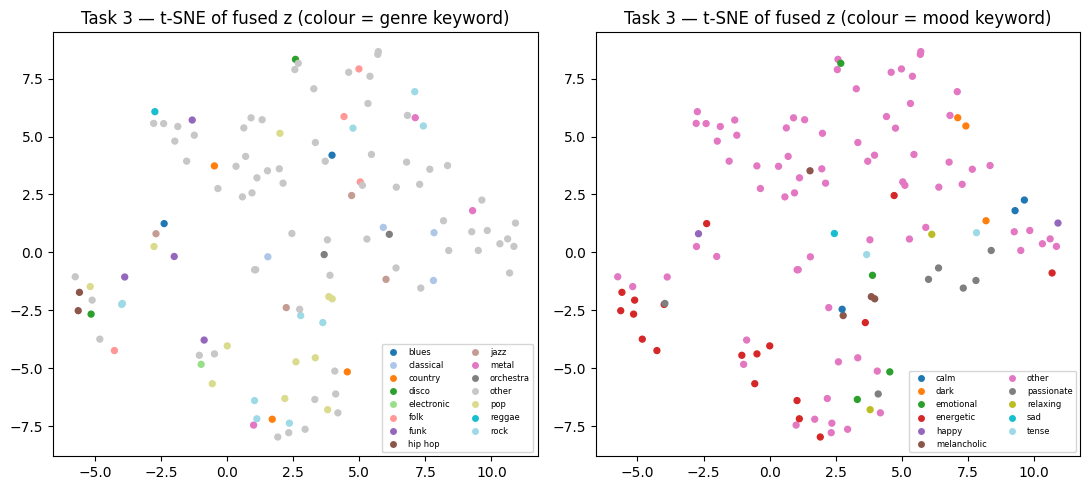

In [24]:
# --- t-SNE of fused z, coloured by genre-keyword and mood-keyword buckets (deliverable) ---
# MusicCaps has no ground-truth genre/mood column, so both are derived here via simple
# keyword matching against the caption text -- a heuristic proxy, documented as such in
# the report, not a ground-truth label.
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

GENRE_WORDS = ["rock","pop","jazz","classical","hiphop","hip hop","electronic","reggae",
               "country","blues","metal","folk","funk","disco","ambient","orchestra"]
MOOD_WORDS  = ["energetic","calm","relaxing","melancholic","melancholy","passionate",
               "emotional","aggressive","happy","sad","dark","uplifting","tense","peaceful"]

def keyword_bucket(text, vocab):
    text = text.lower()
    for w in vocab:
        if w in text:
            return w
    return "other"

m = fusion_models["xattn"].eval()
Z, genre_c, mood_c = [], [], []
with torch.no_grad():
    for i in mc_te:
        b = next(iter(loaders([mc_graphs[i]], [0],[0],[0])[0])).to(DEVICE)
        Z.append(m.embed(b).cpu().numpy()[0])
        cap = mc_graphs[i].caption
        genre_c.append(keyword_bucket(cap, GENRE_WORDS))
        mood_c.append(keyword_bucket(cap, MOOD_WORDS))
Z = np.array(Z)

if len(Z) >= 5:
    emb = TSNE(n_components=2, perplexity=min(30, len(Z)-1), init="random",
               random_state=CONFIG["seed"]).fit_transform(Z)
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, labels, title in zip(axes, [genre_c, mood_c], ["genre keyword", "mood keyword"]):
        cats = sorted(set(labels))
        codes = [cats.index(l) for l in labels]
        ax.scatter(emb[:,0], emb[:,1], c=codes, cmap="tab20", s=18)
        ax.set_title(f"Task 3 — t-SNE of fused z (colour = {title})")
        handles = [plt.Line2D([0],[0], marker='o', color='w',
                    markerfacecolor=plt.cm.tab20(i/max(len(cats)-1,1)), markersize=6, label=c)
                   for i, c in enumerate(cats)]
        ax.legend(handles=handles, fontsize=6, loc="best", ncol=2)
    plt.tight_layout()
    plt.savefig(os.path.join(DIRS["plots"], "task3_tsne.png"), dpi=120); plt.show()
else:
    print("Not enough test points for t-SNE.")

### 3 case studies: graph structure ↔ caption alignment (required deliverable)

For three test clips, plot the segment graph (temporal edges + cosine-similarity
recurrence edges) next to the caption and the fusion model's predicted vs. true tags, so
a reader can see which repeated segments the GNN linked together and whether the
predicted tags track the caption's content.

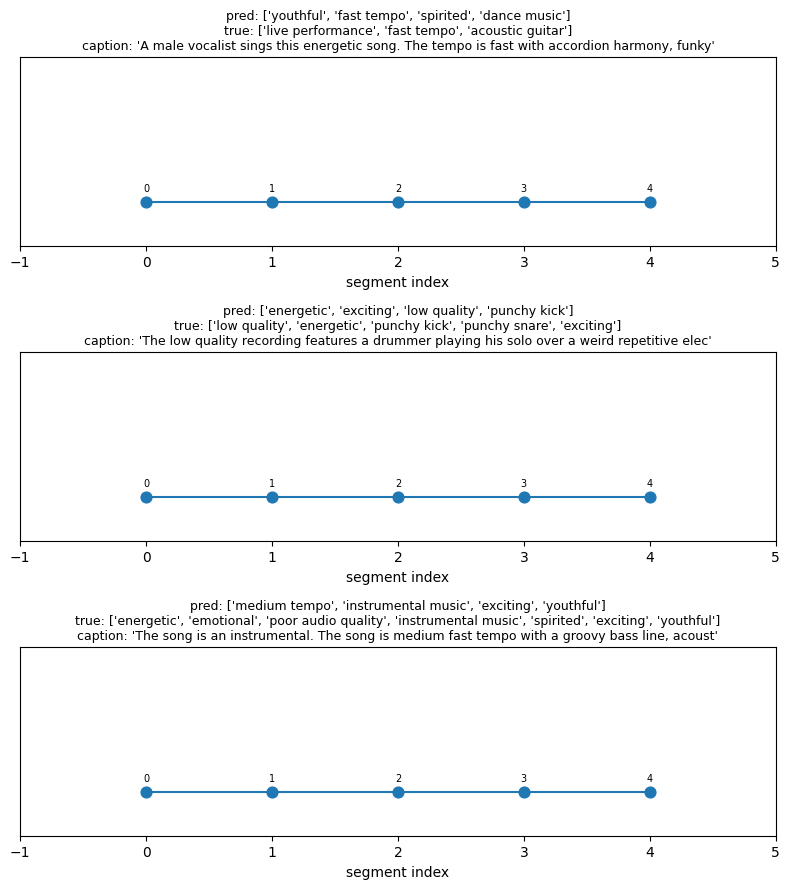

Blue = temporal (adjacent-segment) edges. Orange arcs = recurrence edges (cosine-sim > 0.8), i.e. repeated musical material the GNN links together.


In [25]:
# --- 3 case studies: graph paths + caption/lyric alignment (required deliverable) ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_segment_graph(ax, data, title):
    N = data.x.shape[0]
    xs = np.arange(N)
    ax.scatter(xs, np.zeros(N), s=60, zorder=3, color="#1f77b4")
    for i in range(N):
        ax.annotate(str(i), (xs[i], 0), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=7)
    ei = data.edge_index.numpy()
    for a, b in zip(ei[0], ei[1]):
        if a >= b:
            continue                                    # each undirected edge appears twice; draw once
        if b - a == 1:
            ax.plot([a, b], [0, 0], color="#1f77b4", lw=1.5, zorder=1)          # temporal edge
        else:
            mid, height = (a + b) / 2, 0.15 * (b - a)
            arc = mpatches.Arc((mid, 0), b - a, height * 2, theta1=0, theta2=180, color="#ff7f0e", lw=1.2)
            ax.add_patch(arc)                                                    # recurrence edge
    ax.set_xlim(-1, max(N, 2)); ax.set_ylim(-0.3, max(1.0, 0.15*N))
    ax.set_yticks([]); ax.set_title(title, fontsize=9)
    ax.set_xlabel("segment index")

case_idx = mc_te[:3]
fig, axes = plt.subplots(len(case_idx), 1, figsize=(8, 3*len(case_idx)))
axes = np.atleast_1d(axes)
mdl = fusion_models["xattn"].eval()
for ax, i in zip(axes, case_idx):
    g = mc_graphs[i]
    b = next(iter(loaders([g], [0],[0],[0])[0])).to(DEVICE)
    with torch.no_grad():
        p = torch.sigmoid(mdl(b))[0].cpu().numpy()
    pred = [TAGS[j] for j in p.argsort()[::-1][:4]]
    true = [TAGS[j] for j in range(K) if g.y[0][j] > 0.5] or ["(no tag in top-K vocab)"]
    cap = g.caption[:90]
    plot_segment_graph(ax, g, f"pred: {pred}\ntrue: {true}\ncaption: '{cap}'")
plt.tight_layout()
plt.savefig(os.path.join(DIRS["plots"], "task3_case_studies.png"), dpi=120)
plt.show()
print("Blue = temporal (adjacent-segment) edges. Orange arcs = recurrence edges (cosine-sim > "
      f"{CONFIG['sim_threshold']}), i.e. repeated musical material the GNN links together.")

## 9 · Task 4 (Advanced) — Contrastive dual-encoder + retrieval

Audio-graph and caption encoders are pulled into a shared space with symmetric **InfoNCE**;
we report caption→audio and audio→caption **R@1/5/10** on held-out pairs.

In [26]:
import torch, torch.nn as nn, torch.nn.functional as F

class DualEncoder(nn.Module):
    def __init__(self, d=128, proj=128, dropout=0.2):
        super().__init__()
        self.gnn  = GNNEncoder(out=d)
        self.bert = AutoModel.from_pretrained(CONFIG["bert_model"])
        self.gp = nn.Sequential(nn.Dropout(dropout), nn.Linear(d, proj))
        self.tp = nn.Sequential(nn.Dropout(dropout), nn.Linear(self.bert.config.hidden_size, proj))
        self.logit_scale = nn.Parameter(torch.tensor(2.6592))            # ln(1/0.07)
    def encode_graph(self, data):
        return F.normalize(self.gp(self.gnn(data.x, data.edge_index, data.batch)), dim=-1)
    def encode_text(self, ids, am):
        cls = self.bert(input_ids=ids, attention_mask=am).last_hidden_state[:,0]
        return F.normalize(self.tp(cls), dim=-1)

def info_nce(g, t, scale):
    logits = scale * g @ t.t()                                            # [B,B]
    labels = torch.arange(g.size(0), device=g.device)
    return 0.5*(F.cross_entropy(logits, labels) + F.cross_entropy(logits.t(), labels))

def recall_at_k(G, T, ks=(1,5,10)):
    sims = G @ T.t()                                                      # rows=graph query
    ranks_ga = sims.argsort(dim=1, descending=True)
    ranks_ag = sims.t().argsort(dim=1, descending=True)
    n = G.size(0); out = {}
    for k in ks:
        ga = sum(i in ranks_ga[i,:k] for i in range(n))/n
        ag = sum(i in ranks_ag[i,:k] for i in range(n))/n
        out[f"audio2cap_R@{k}"] = round(ga,3); out[f"cap2audio_R@{k}"] = round(ag,3)
    return out

In [27]:
# --- Train contrastive + evaluate retrieval ---
dual = DualEncoder().to(DEVICE)
opt = torch.optim.AdamW(dual.parameters(), lr=2e-5, weight_decay=CONFIG["weight_decay"])
tr_ld, va_ld, te_ld = loaders(mc_graphs, mc_tr, mc_va, mc_te, bs=max(16, CONFIG["batch_size"]))

def encode_split(model, loader):
    model.eval(); Gs, Ts = [], []
    with torch.no_grad():
        for b in loader:
            b = b.to(DEVICE)
            Gs.append(model.encode_graph(b)); Ts.append(model.encode_text(b.input_ids, b.attention_mask))
    return torch.cat(Gs), torch.cat(Ts)

best_score, best_state, bad_epochs = -1.0, None, 0
for ep in range(CONFIG["epochs_clip"]):
    dual.train(); tot = 0
    for b in tr_ld:
        b = b.to(DEVICE); opt.zero_grad()
        g = dual.encode_graph(b); t = dual.encode_text(b.input_ids, b.attention_mask)
        loss = info_nce(g, t, dual.logit_scale.exp().clamp(max=100)); loss.backward(); opt.step()
        tot += loss.item()
    Gv, Tv = encode_split(dual, va_ld)
    val_r5 = np.mean(list(recall_at_k(Gv, Tv, ks=(5,)).values()))    # early-stop signal = val R@5
    print(f"ep{ep+1} nce_loss={tot/len(tr_ld):.3f} val_meanR@5={val_r5:.3f}")
    if val_r5 > best_score:
        best_score, bad_epochs = val_r5, 0
        best_state = {k: v.cpu().clone() for k, v in dual.state_dict().items()}
    else:
        bad_epochs += 1
    if bad_epochs >= CONFIG["patience"]:
        print(f"Early stop at ep{ep+1} (no val R@5 improvement for {CONFIG['patience']} epochs)."); break

dual.load_state_dict(best_state)
G, T = encode_split(dual, te_ld)
task4_metrics = recall_at_k(G, T)
print("TASK 4 retrieval (best val-selected checkpoint):", task4_metrics)
torch.save(dual.state_dict(), os.path.join(DIRS["checkpoints"],"task4_dual.pt"))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ep1 nce_loss=2.899 val_meanR@5=0.029
ep2 nce_loss=2.791 val_meanR@5=0.041
ep3 nce_loss=2.779 val_meanR@5=0.033
ep4 nce_loss=2.734 val_meanR@5=0.033
ep5 nce_loss=2.749 val_meanR@5=0.033
ep6 nce_loss=2.739 val_meanR@5=0.033
ep7 nce_loss=2.714 val_meanR@5=0.033
ep8 nce_loss=2.704 val_meanR@5=0.029
ep9 nce_loss=2.715 val_meanR@5=0.062
ep10 nce_loss=2.680 val_meanR@5=0.042
ep11 nce_loss=2.665 val_meanR@5=0.045
ep12 nce_loss=2.680 val_meanR@5=0.037
ep13 nce_loss=2.615 val_meanR@5=0.038
ep14 nce_loss=2.572 val_meanR@5=0.045
ep15 nce_loss=2.535 val_meanR@5=0.033
ep16 nce_loss=2.498 val_meanR@5=0.054
ep17 nce_loss=2.416 val_meanR@5=0.025
Early stop at ep17 (no val R@5 improvement for 8 epochs).
TASK 4 retrieval (best val-selected checkpoint): {'audio2cap_R@1': 0.008, 'cap2audio_R@1': 0.008, 'audio2cap_R@5': 0.041, 'cap2audio_R@5': 0.041, 'audio2cap_R@10': 0.099, 'cap2audio_R@10': 0.091}


In [28]:
# --- 10 qualitative retrieval examples: caption query -> top-3 clips ---
import os
te_captions = [mc_graphs[i].caption for i in mc_te]
sims = (T @ G.t()).cpu().numpy()                                          # text query rows
lines = []
for qi in range(min(10, len(te_captions))):
    top3 = sims[qi].argsort()[::-1][:3]
    lines.append(f"QUERY: {te_captions[qi][:80]}")
    for r, ci in enumerate(top3):
        mark = "  <-- correct" if ci == qi else ""
        lines.append(f"   {r+1}. {te_captions[ci][:70]}{mark}")
    lines.append("")
open(os.path.join(DIRS["retrieval_examples"],"caption2audio_top3.txt"),"w").write("\n".join(lines))
print("\n".join(lines[:22]))

QUERY: A male vocalist sings this energetic song. The tempo is fast with accordion harm
   1. The track is an upbeat blues song that features falsetto and raspy mal
   2. The low quality recording features a classical song that consists of a
   3. This disco song features a male voice singing the main melody. This is

QUERY: The low quality recording features a drummer playing his solo over a weird repet
   1. These are sounds coming from an advertisement. There are sound effects
   2. This clip features an electric guitar played through a distortion effe
   3. The song is an instrumental with separate audio tracks. The tempos are

QUERY: The song is an instrumental. The song is medium fast tempo with a groovy bass li
   1. This clip features an electric guitar played through a distortion effe
   2. This music is a percussion solo. The tempo is fast with the drummer  p
   3. The low quality recording features a classical song that consists of a

QUERY: The song is an instrumental. The 

## 10 · Baselines, aggregate metrics & end-to-end demo

Random-tag baseline (**B1**), a consolidated results table written to `results/metrics.json`,
and a single-clip inference demo (this cell is your required `demo_context.ipynb` core).

In [29]:
# --- B1 random baseline + write metrics.json ---
import json, numpy as np, os
rng = np.random.default_rng(CONFIG["seed"])
y_true = np.stack([mc_graphs[i].y[0].numpy() for i in mc_te])
rand = rng.random(y_true.shape)
b1 = multilabel_metrics(y_true, rand)                      # random baseline, same 0.5 threshold, as a reference point

results = {
    "B1_random_tags": b1,
    "task1_bert_thr0.5": task1_metrics_raw,
    "task1_bert_tuned_thr": task1_metrics,
    "task2_gnn_acc": gnn_acc, "task2_cnn_acc": cnn_acc,
    "task3_ablation": ablation,
    "task4_retrieval": task4_metrics,
    "tag_vocab_size": K, "n_musiccaps": len(mc_graphs), "n_gtzan": len(gtzan_graphs),
}
json.dump(results, open(os.path.join(DIRS["results"],"metrics.json"),"w"), indent=2)
print(json.dumps(results, indent=2))

{
  "B1_random_tags": {
    "macro_f1": 0.0962006478437158,
    "micro_f1": 0.10075414781297135,
    "auc_pr": 0.08320869680040487
  },
  "task1_bert_thr0.5": {
    "macro_f1": 0.39079051167209683,
    "micro_f1": 0.4162203519510329,
    "auc_pr": 0.5260374530498977
  },
  "task1_bert_tuned_thr": {
    "macro_f1": 0.41648257186115983,
    "micro_f1": 0.4206426484907498,
    "auc_pr": 0.5260374530498977
  },
  "task2_gnn_acc": 0.38666666666666666,
  "task2_cnn_acc": 0.6533333333333333,
  "task3_ablation": {
    "bert": {
      "macro_f1": 0.4729260169337779,
      "micro_f1": 0.5447470817120622,
      "auc_pr": 0.5802656390560016
    },
    "gnn": {
      "macro_f1": 0.09131192849231069,
      "micro_f1": 0.12603648424543948,
      "auc_pr": 0.09997287330259545
    },
    "concat": {
      "macro_f1": 0.46811079681312356,
      "micro_f1": 0.5375,
      "auc_pr": 0.601604149818486
    },
    "xattn": {
      "macro_f1": 0.5037047657902639,
      "micro_f1": 0.5603985056039851,
      "au

In [30]:
# --- End-to-end demo: one clip -> predicted tags (fusion) + best-matching caption ---
import torch
demo = mc_graphs[mc_te[0]]
mdl = fusion_models["xattn"].eval()
with torch.no_grad():
    b = next(iter(loaders([demo], [0],[0],[0])[0])).to(DEVICE)
    probs = torch.sigmoid(mdl(b))[0].cpu().numpy()
pred_tags = [TAGS[i] for i in probs.argsort()[::-1][:6]]
print("DEMO CLIP:", demo.ytid if hasattr(demo,'ytid') else "(musiccaps test clip)")
print("True caption:", demo.caption[:110])
print("Predicted context tags (GNN-BERT fusion):", pred_tags)

with torch.no_grad():
    gvec = dual.encode_graph(b)
    best = (gvec @ T.t()).argmax().item()
print("Contrastive best-matching caption:", te_captions[best][:110])

DEMO CLIP: (musiccaps test clip)
True caption: A male vocalist sings this energetic song. The tempo is fast with accordion harmony, funky bass lines, vigorou
Predicted context tags (GNN-BERT fusion): ['youthful', 'fast tempo', 'spirited', 'dance music', 'pop', 'male singer']
Contrastive best-matching caption: This audio contains a shofar horn getting blown in a higher register. The high tone is loud and drops in pitch


In [31]:
i = mc_te[8]                          # change the index to test other clips
g = mc_graphs[i]
b = next(iter(loaders([g], [0], [0], [0])[0])).to(DEVICE)
with torch.no_grad():
    p = torch.sigmoid(fusion_models["xattn"](b))[0].cpu().numpy()
pred = [TAGS[j] for j in p.argsort()[::-1][:6]]
true = [TAGS[j] for j in range(len(TAGS)) if g.y[0][j] > 0.5]
print("caption:   ", g.caption[:100])
print("predicted: ", pred)
print("ground truth:", true)

caption:    The low quality recording features a sound of a digital bell, followed by crowd noises in the backgr
predicted:  ['low quality', 'noisy', 'mono', 'loud', 'passionate', 'energetic']
ground truth: ['low quality', 'noisy', 'mono']


## 11 · Packaging for submission

Everything needed by the rubric is now on Drive under `gnn_bert_music/`:
`graphs/` (≥20 example graphs), `results/metrics.json`, `plots/` (F1, t-SNE),
`retrieval_examples/`, `checkpoints/`.

**Next step for the repo:** split the model classes into `src/*.py`
(`bert_encoder.py`, `gnn_model.py`, `fusion_model.py`, `contrastive.py`) and keep this
notebook as `notebooks/demo_context.ipynb`. Write the 6–10 page report from the numbers in
`metrics.json` and the two plots.

**Tuning knobs if you have time / GPU budget:** raise `musiccaps_n`, `epochs_*`,
switch `bert_model` to `bert-base-uncased`, add GAT, or plug in DEAM for the valence/arousal
auxiliary loss in Task 3.

In [32]:
from IPython.display import Audio, display
import pandas as pd, os, torch

man = pd.read_csv(os.path.join(DIRS["processed"], "musiccaps_manifest.csv"))
cap2wav = dict(zip(man["caption"], man["wav"]))

query = "a melancholic piano melody with soft strings"   # <-- edit this freely
dual.eval()
enc = TOK(query, truncation=True, padding="max_length",
          max_length=CONFIG["max_text_len"], return_tensors="pt").to(DEVICE)
with torch.no_grad():
    q = dual.encode_text(enc["input_ids"], enc["attention_mask"])
sims = (q @ G.t())[0]
for rank, idx in enumerate(sims.argsort(descending=True)[:3].cpu().tolist()):
    cap = te_captions[idx]
    print(f"#{rank+1}  {cap[:100]}")
    w = cap2wav.get(cap)
    if w and os.path.exists(w):
        display(Audio(w))

#1  This song features an acoustic guitar playing chords using only down strokes. There are only two cho


#2  This clip features an electric guitar played through a distortion effects pedal. At the beginning, t


#3  The song is an instrumental with separate audio tracks. The tempos are medium with female vocals, ba
